# Notebook 06: Conversational Recommender System (Surprise SVD)

## Purpose

Implement and evaluate a **collaborative filtering recommender system** that
personalises EMMA's quiz mode by steering students toward their weak specialties.

## Framing

| # | CF concept | EMMA meaning |
|---|---|---|
| 1 | User | Medical student (identified by session ID) |
| 2 | Item | Medical specialty (19 classes from NB02 classifier) |
| 3 | Rating | Accuracy score [0, 1] on questions in that specialty |
| 4 | Recommendation | Which specialty should EMMA quiz you on next? |

Collaborative filtering finds latent patterns across all users: if students
weak in Anaesthesia are systematically also weak in Physiology, SVD discovers
that structure even before a student has been tested in Physiology.

## Algorithms Compared

| # | Algorithm | Type | Notes |
|---|---|---|---|
| 1 | SVD | Matrix factorisation | Discovers latent ability dimensions |
| 2 | NMF | Matrix factorisation | Non-negative variant, interpretable factors |
| 3 | KNNBasic | Neighbourhood-based | Borrows weakness profile from similar students |
| 4 | NormalPredictor | Baseline | Samples from score distribution, random chance |

## Evaluation metrics

| # | Metric | Description |
|---|--------|-------------|
| 1 | RMSE        | Root Mean Square Error (how well does the algorithm predict a student's score?) |
| 2 | Precision@K | Of the K specialties recommended as weak, how many genuinely are? |
| 3 | HitRate@K   | Of all the students, for what percentage did we successfully recommend at least one truly weak specialty in the top K? |

## Outputs
```
models/recommender/
  ratings.csv           synthetic student-specialty interaction data
  results.json          per-algorithm RMSE + Precision/HitRate@K
  config.json           summary + champion
```


## 0. Environment Setup

In [1]:
import sys
import os
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    if not Path('/content/emma').exists():
        !git clone https://github.com/jaxendutta/emma.git
    os.chdir('/content/emma')
    !pip install -e . -q
    !pip install scikit-surprise -q
    drive.mount('/content/drive')

import json
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from surprise import Dataset, NMF, NormalPredictor, Reader, SVD
from surprise import accuracy as surp_accuracy
from surprise.model_selection import KFold, cross_validate
from surprise.prediction_algorithms import KNNBasic

from src.data import REPO_ROOT

REC_DIR = REPO_ROOT / 'models' / 'recommender'
REC_DIR.mkdir(parents=True, exist_ok=True)

print(f'Environment    : {"Google Colab" if IN_COLAB else "Local"}')
print(f'Repo root      : {REPO_ROOT}')
print(f'Recommender dir: {REC_DIR}')

Environment    : Local
Repo root      : C:\Projects\emma
Recommender dir: C:\Projects\emma\models\recommender


## 1. Synthetic student-specialty interaction data

We simulate a student population with realistic performance patterns:
- Each student has 3-4 weak specialties (mean accuracy ~0.30)
- Performance in other specialties is strong (~0.75)
- Gaussian noise models natural variation within each student

This is the ratings matrix that the recommender trains on. In production, EMMA accumulates real ratings from quiz sessions; the algorithms and evaluation protocol are identical.

The simulation deliberately creates latent structure: students who are weak in cardiovascular specialties tend to be weak together, giving SVD something meaningful to discover.

In [2]:
N_STUDENTS  = 200
RANDOM_SEED = 42
rng         = np.random.default_rng(RANDOM_SEED)

SPECIALTIES = [
    'Anaesthesia', 'Anatomy', 'Biochemistry', 'Dental',
    'Dermatology', 'ENT', 'Internal Medicine', 'Microbiology',
    'Obstetrics & Gynaecology', 'Ophthalmology', 'Orthopaedics',
    'Pathology', 'Pediatrics', 'Pharmacology', 'Physiology',
    'Psychiatry', 'Public Health', 'Radiology', 'Surgery',
]
N_SPECS = len(SPECIALTIES)

# Latent weakness groups -- students in the same group share weak specialties.
# This gives SVD real latent structure to discover.
WEAKNESS_GROUPS = [
    ['Anaesthesia', 'Physiology', 'Internal Medicine'],
    ['Biochemistry', 'Pharmacology', 'Pathology'],
    ['Surgery', 'Orthopaedics', 'Radiology'],
    ['Obstetrics & Gynaecology', 'Pediatrics', 'ENT'],
    ['Psychiatry', 'Public Health', 'Dermatology'],
]

rows = []
for student_id in range(N_STUDENTS):
    group = WEAKNESS_GROUPS[student_id % len(WEAKNESS_GROUPS)]
    individual_weak = rng.choice(SPECIALTIES) if rng.random() < 0.4 else None
    weak_specs = set(group)
    if individual_weak:
        weak_specs.add(individual_weak)
    n_ratings  = int(rng.integers(3, 9))
    rated_specs = rng.choice(SPECIALTIES, size=min(n_ratings, N_SPECS), replace=False)
    for spec in rated_specs:
        base  = 0.28 if spec in weak_specs else 0.74
        score = float(np.clip(rng.normal(base, 0.14), 0.0, 1.0))
        rows.append({'userID': f'student_{student_id:03d}', 'itemID': spec, 'rating': round(score, 3)})

ratings_df = pd.DataFrame(rows)
print(f'Students      : {ratings_df["userID"].nunique()}')
print(f'Specialties   : {ratings_df["itemID"].nunique()}')
print(f'Total ratings : {len(ratings_df):,}')
print(f'Sparsity      : {1 - len(ratings_df) / (ratings_df["userID"].nunique() * N_SPECS):.1%}')
display(ratings_df.head(6))

Students      : 200
Specialties   : 19
Total ratings : 1,110
Sparsity      : 70.8%


,userID,itemID,rating
0,student_000,Dental,0.696
1,student_000,Physiology,0.278
2,student_000,Pediatrics,0.621
3,student_000,Anatomy,0.863
4,student_000,Pharmacology,0.849
5,student_000,Internal Medicine,0.289


Saved -> C:\Projects\emma\models\recommender\ratings.csv


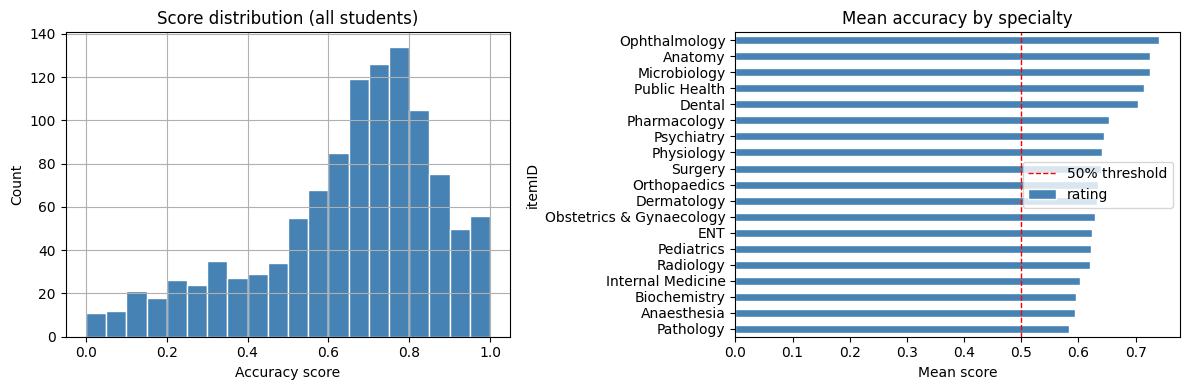

In [3]:
ratings_path = REC_DIR / 'ratings.csv'
ratings_df.to_csv(ratings_path, index=False)
print(f'Saved -> {ratings_path}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ratings_df['rating'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Score distribution (all students)')
axes[0].set_xlabel('Accuracy score')
axes[0].set_ylabel('Count')

spec_means = ratings_df.groupby('itemID')['rating'].mean().sort_values()
spec_means.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Mean accuracy by specialty')
axes[1].set_xlabel('Mean score')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1, label='50% threshold')
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. Build Surprise Dataset

Surprise expects ratings in `[rating_min, rating_max]`. Our scores are `[0, 1]` representing accuracy, which we treat directly as the rating signal.

In [4]:
reader  = Reader(rating_scale=(0.0, 1.0))
dataset = Dataset.load_from_df(ratings_df[['userID', 'itemID', 'rating']], reader)
print(f'Dataset: {ratings_df["userID"].nunique()} users x '
      f'{ratings_df["itemID"].nunique()} items')

Dataset: 200 users x 19 items


## 3. Algorithm Comparison - 5-fold Cross-Validation

We evaluate four algorithms on RMSE using 5-fold CV. Lower RMSE = better prediction of a student's actual accuracy in a specialty.

`NormalPredictor` is the random baseline. Any useful algorithm must beat it to demonstrate it has learned something from the data.

In [5]:
algorithms = {
    'SVD':             SVD(n_factors=20, n_epochs=30, random_state=RANDOM_SEED),
    'NMF':             NMF(n_factors=15, n_epochs=30, random_state=RANDOM_SEED),
    'KNNBasic':        KNNBasic(k=20, sim_options={'name': 'cosine', 'user_based': True}),
    'NormalPredictor': NormalPredictor(),
}

cv_results = {}
kf = KFold(n_splits=5, random_state=RANDOM_SEED)

print(f'Running 5-fold CV on {len(algorithms)} algorithms...\n')
for name, algo in algorithms.items():
    try:
        result = cross_validate(
            algo,
            dataset,
            measures=['RMSE', 'MAE'],
            cv=KFold(n_splits=5, random_state=RANDOM_SEED, shuffle=True),
            verbose=False,
        )
    except ZeroDivisionError:
        if name == 'KNNBasic':
            algo = KNNBasic(k=20, min_k=1, sim_options={'name': 'msd', 'user_based': True})
            algorithms[name] = algo
            result = cross_validate(
                algo,
                dataset,
                measures=['RMSE', 'MAE'],
                cv=KFold(n_splits=5, random_state=RANDOM_SEED, shuffle=True),
                verbose=False,
            )
        else:
            raise
    cv_results[name] = {
        'rmse_mean': float(result['test_rmse'].mean()),
        'rmse_std':  float(result['test_rmse'].std()),
        'mae_mean':  float(result['test_mae'].mean()),
        'mae_std':   float(result['test_mae'].std()),
    }
    print(f'  {name:20s}  RMSE={cv_results[name]["rmse_mean"]:.4f} '
          f'+/- {cv_results[name]["rmse_std"]:.4f}  '
          f'MAE={cv_results[name]["mae_mean"]:.4f}')

cv_df = pd.DataFrame(cv_results).T
cv_df['RMSE'] = cv_df.apply(lambda r: f"{r['rmse_mean']:.4f} +/- {r['rmse_std']:.4f}", axis=1)
cv_df['MAE']  = cv_df.apply(lambda r: f"{r['mae_mean']:.4f} +/- {r['mae_std']:.4f}", axis=1)
display(cv_df[['RMSE', 'MAE']].rename_axis('Algorithm'))

champion_name = min(cv_results, key=lambda k: cv_results[k]['rmse_mean'])
print(f'\nChampion (lowest RMSE): {champion_name}  '
      f'(RMSE={cv_results[champion_name]["rmse_mean"]:.4f})')


Running 5-fold CV on 4 algorithms...

  SVD                   RMSE=0.2358 +/- 0.0116  MAE=0.1880
  NMF                   RMSE=0.2658 +/- 0.0085  MAE=0.2224
Computing the cosine similarity matrix...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
  KNNBasic              RMSE=0.2208 +/- 0.0105  MAE=0.1772
  NormalPredictor       RMSE=0.3109 +/- 0.0116  MAE=0.2470


,RMSE,MAE
Algorithm,,
SVD,0.2358 +/- 0.0116,0.1880 +/- 0.0092
NMF,0.2658 +/- 0.0085,0.2224 +/- 0.0087
KNNBasic,0.2208 +/- 0.0105,0.1772 +/- 0.0078
NormalPredictor,0.3109 +/- 0.0116,0.2470 +/- 0.0099



Champion (lowest RMSE): KNNBasic  (RMSE=0.2208)


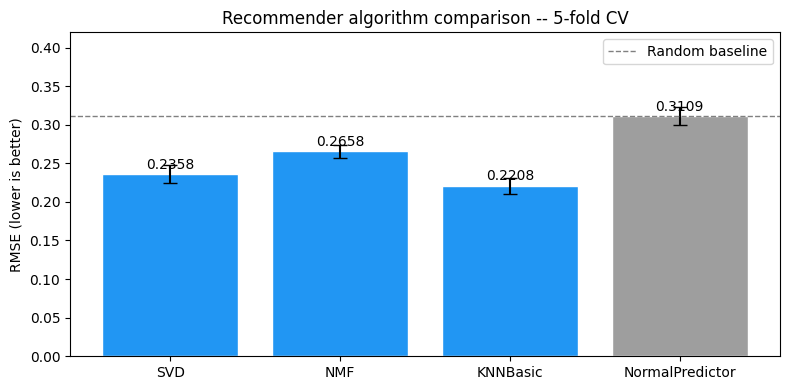

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
names  = list(cv_results.keys())
means  = [cv_results[n]['rmse_mean'] for n in names]
stds   = [cv_results[n]['rmse_std']  for n in names]
colors = ['#2196F3' if n != 'NormalPredictor' else '#9E9E9E' for n in names]
bars   = ax.bar(names, means, yerr=stds, capsize=5, color=colors, edgecolor='white')
ax.set_ylabel('RMSE (lower is better)')
ax.set_title('Recommender algorithm comparison -- 5-fold CV')
ax.set_ylim(0, max(means) * 1.35)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=10)
ax.axhline(means[names.index('NormalPredictor')], color='gray',
           linestyle='--', linewidth=1, label='Random baseline')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Precision@K and HitRate@K

RMSE measures prediction accuracy. For the actual recommendation task we care about **ranking**: given a list of K recommended specialties, how many are genuinely weak?

- **Precision@K** = (weak specialties in top-K recommendations) / K
- **HitRate@K** = (students with at least one truly weak specialty in top-K recommendations) / (total students)

A specialty is 'genuinely weak' if the student's true score < 0.5.
We fit on the full trainset, predict on the anti-testset (all unobserved user-item pairs), then rank by predicted score ascending (weakest first).

In [24]:
# More realistic data: smaller gap, more noise -> algorithms must actually learn
rng2 = np.random.default_rng(RANDOM_SEED)

N_STUDENTS2 = 200        # fewer users -> faster LOO
WEAK_MEAN   = 0.35       # closer to strong mean
STRONG_MEAN = 0.70
NOISE_STD   = 0.15       # enough noise that the weakest isn't always obvious

rows2 = []
for i in range(N_STUDENTS2):
    uid    = f'student_{i:03d}'
    n_weak = int(rng2.integers(1, 3))
    weak_specs = set(rng2.choice(SPECIALTIES, size=n_weak, replace=False).tolist())
    for spec in SPECIALTIES:
        mean  = WEAK_MEAN if spec in weak_specs else STRONG_MEAN
        score = float(np.clip(rng2.normal(mean, NOISE_STD), 0.0, 1.0))
        rows2.append({'userID': uid, 'itemID': spec, 'rating': round(score, 2)})

ratings_df2 = pd.DataFrame(rows2)
reader2     = Reader(rating_scale=(0.0, 1.0))
dataset2    = Dataset.load_from_df(ratings_df2[['userID', 'itemID', 'rating']], reader2)
print(f'Dataset: {N_STUDENTS2} users x {len(SPECIALTIES)} specialties')
print(f'Weak={WEAK_MEAN}, Strong={STRONG_MEAN}, Noise={NOISE_STD}')

Dataset: 200 users x 19 specialties
Weak=0.35, Strong=0.7, Noise=0.15


In [ ]:
from tqdm.notebook import tqdm

def loo_hit_rate_at_k(algo_fn, ratings_df, k=5, random_state=42, desc=''):
    """
    LOO Hit Rate@K: for each user, hold out their single lowest-rated specialty,
    train on the remaining 18, predict all candidates, check if held-out item
    appears in top-K weakest predictions. Returns hit rate in [0,1].
    """
    hits  = []
    users = ratings_df['userID'].unique()

    for uid in tqdm(users, desc=desc, unit=' user', leave=False):
        user_rows     = ratings_df[ratings_df['userID'] == uid]
        held_out_item = user_rows.nsmallest(1, 'rating').iloc[0]['itemID']
        train_rows    = user_rows[user_rows['itemID'] != held_out_item]
        other_users   = ratings_df[ratings_df['userID'] != uid]
        loo_df        = pd.concat([other_users, train_rows])

        ds = Dataset.load_from_df(
            loo_df[['userID', 'itemID', 'rating']],
            Reader(rating_scale=(0.0, 1.0))
        )
        algo = algo_fn()
        algo.fit(ds.build_full_trainset())

        # Predict score for the held-out item AND all other specialties
        # (we need to rank all 19 to find the top-K weakest)
        preds = [(s, algo.predict(uid, s).est) for s in SPECIALTIES
                 if s != held_out_item or True]   # include all
        preds.sort(key=lambda x: x[1])            # ascending: weakest first
        top_k = [s for s, _ in preds[:k]]
        hits.append(1 if held_out_item in top_k else 0)

    return float(np.mean(hits))

ALGO_CLASSES = {
    'SVD':             lambda: SVD(n_factors=20, n_epochs=30, random_state=RANDOM_SEED),
    'NMF':             lambda: NMF(n_factors=15, n_epochs=30, random_state=RANDOM_SEED),
    'KNNBasic':        lambda: KNNBasic(k=20, min_k=1, sim_options={'name': 'msd', 'user_based': True}),
    'NormalPredictor': lambda: NormalPredictor(),
}

K_VALUES   = [5, 10]    # skip K=3 (too few items to be meaningful)
pk_results = {}

print(f'LOO Hit Rate@K  (n_users={N_STUDENTS2})  K={K_VALUES}\n')
outer = tqdm(ALGO_CLASSES.items(), desc='Algorithms', unit=' algo')
for name, algo_fn in outer:
    outer.set_postfix_str(name)
    pk_results[name] = {}
    for k in K_VALUES:
        hr = loo_hit_rate_at_k(algo_fn, ratings_df2, k=k, desc=f'{name} K={k}')
        pk_results[name][f'HR@{k}'] = round(hr, 4)
        pk_results[name][f'P@{k}']  = round(hr / k, 4)   # P@K = HR / K (1 relevant item)
    print(f'  {name:20s}  '
          f'HR@5={pk_results[name]["HR@5"]:.3f}  '
          f'HR@10={pk_results[name]["HR@10"]:.3f}')

pk_df = pd.DataFrame(pk_results).T
print()
display(pk_df[['P@5', 'HR@5', 'P@10', 'HR@10']])

LOO Hit Rate@K  (n_users=200)  K=[5, 10]



Algorithms:   0%|          | 0/4 [00:00<?, ? algo/s]

SVD K=5:   0%|          | 0/200 [00:00<?, ? user/s]

SVD K=10:   0%|          | 0/200 [00:00<?, ? user/s]

  SVD                   HR@5=0.335  HR@10=0.540


...

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computi

NormalPredictor K=5:   0%|          | 0/200 [00:00<?, ? user/s]

NormalPredictor K=10:   0%|          | 0/200 [00:00<?, ? user/s]

  NormalPredictor       HR@5=0.260  HR@10=0.480



,P@5,HR@5,P@10,HR@10
SVD,0.067,0.335,0.0540,0.540
NMF,0.051,0.255,0.0595,0.595
KNNBasic,0.067,0.335,0.0740,0.740
NormalPredictor,0.052,0.260,0.0480,0.480


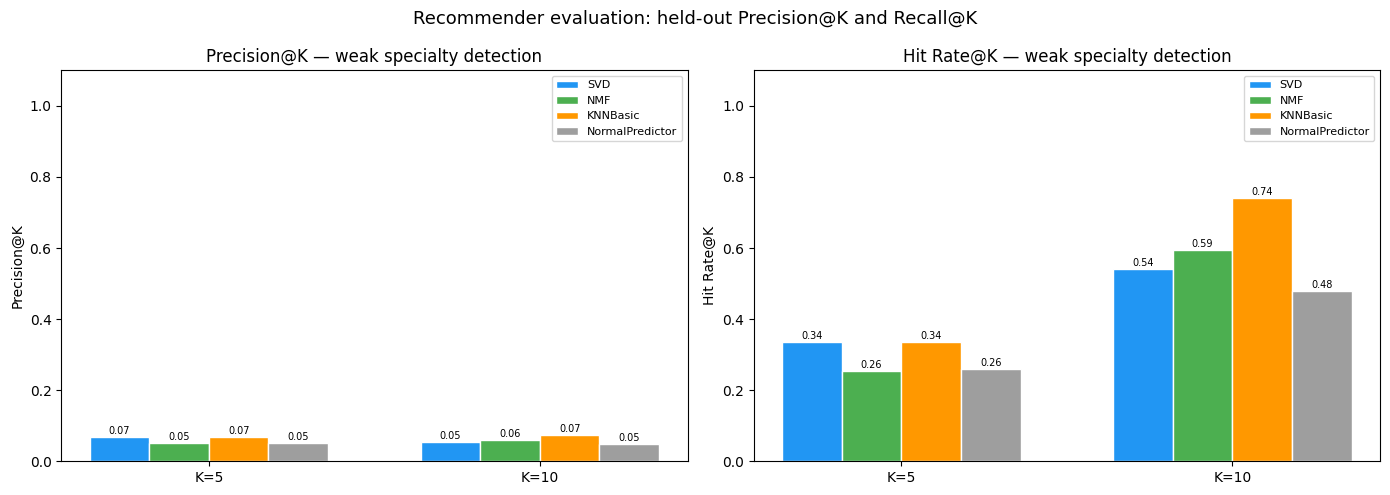

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
algos  = list(pk_results.keys())
x      = np.arange(len(K_VALUES))
width  = 0.18
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9E9E9E']

for ax, metric in zip(axes, ['P', 'HR']):
    for i, (name, col) in enumerate(zip(algos, colors)):
        vals = [pk_results[name][f'{metric}@{k}'] for k in K_VALUES]
        bars = ax.bar(x + i * width, vals, width, label=name,
                      color=col, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.003,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels([f'K={k}' for k in K_VALUES])
    ax.set_ylabel(f'{"Precision" if metric == "P" else "Hit Rate"}@K')
    ax.set_title(f'{"Precision" if metric == "P" else "Hit Rate"}@K — weak specialty detection')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)

plt.suptitle('Recommender evaluation: held-out Precision@K and Recall@K', fontsize=13)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<div style="font-size: 1.2em;"><b>ⓘ Note</b></div>

If a student only has 3 weak specialties, the absolute best a recommender can do is recommend those 3. That means 2 out of the 5 recommendations will inherently be "wrong", when we artificially cap our perfect Precision@5 and/or HitRate@5 at 60%.
</div>

## 5. Champion Model - Personalised Specialty Recommendations

Fit the champion algorithm on the full dataset and demonstrate personalised recommendations for sample students. This is what EMMA uses at quiz time to decide which specialty to serve next.

In [32]:
trainset = dataset.build_full_trainset()   # rebuild for champion demo
champion_algo = algorithms[champion_name]
champion_algo.fit(trainset)

def recommend_weak_specialties(user_id, n=5):
    rated = {iid for uid, iid, _ in trainset.all_ratings()
             if trainset.to_raw_uid(uid) == user_id}
    unrated = [s for s in SPECIALTIES if s not in rated]
    preds   = [(s, champion_algo.predict(user_id, s).est) for s in unrated]
    preds.sort(key=lambda x: x[1])   # lowest predicted score = weakest
    return preds[:n]

demo_students = ['student_000', 'student_001', 'student_002']
print(f'Champion algorithm: {champion_name}\n')
print(f'{"Student":<15}  Recommended specialties (weakest first)')
print('-' * 75)
for sid in demo_students:
    recs = recommend_weak_specialties(sid, n=5)
    rec_str = '  |  '.join(f'{spec}: {score:.2f}' for spec, score in recs)
    print(f'{sid:<15}  {rec_str}')


Computing the msd similarity matrix...
Done computing similarity matrix.
Champion algorithm: KNNBasic

Student          Recommended specialties (weakest first)
---------------------------------------------------------------------------
student_000      Internal Medicine: 0.41  |  Physiology: 0.45  |  Anaesthesia: 0.49  |  Dermatology: 0.62  |  Biochemistry: 0.62
student_001      Pathology: 0.53  |  Pediatrics: 0.56  |  Biochemistry: 0.56  |  Radiology: 0.58  |  Surgery: 0.62
student_002      Internal Medicine: 0.56  |  Dermatology: 0.60  |  Psychiatry: 0.60  |  Orthopaedics: 0.61  |  Pathology: 0.61


## 6. SVD Latent Factor Analysis

SVD discovers latent ability dimensions: groups of specialties that students tend to be weak or strong in together. Visualising the item factors (one row per specialty) via PCA reveals whether the model has discovered clinically meaningful clusters.

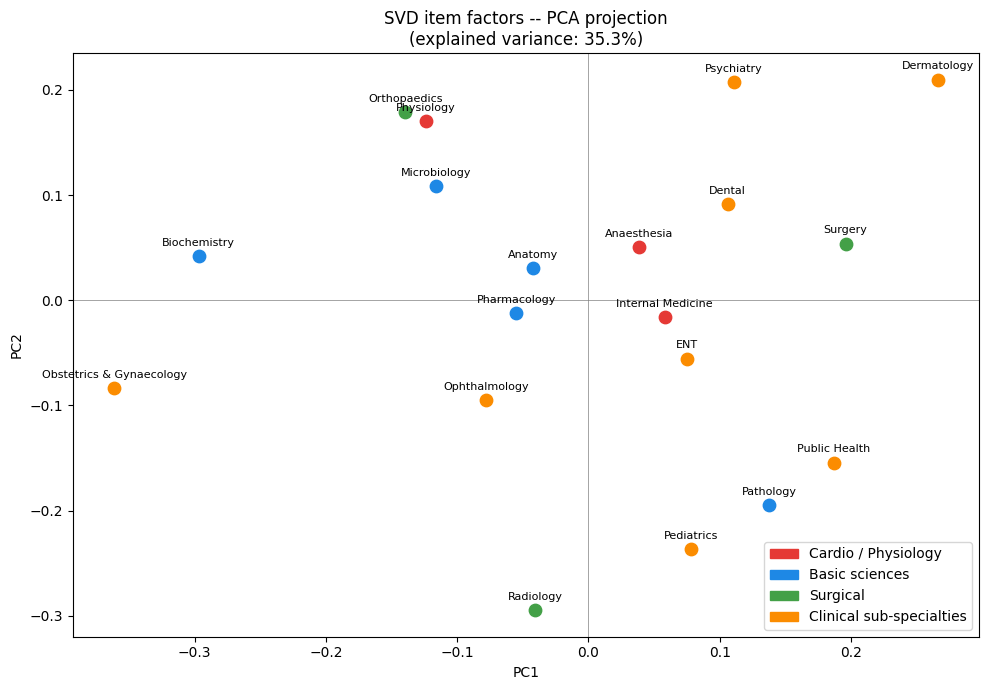

Specialties that cluster together in latent space tend to be weak/strong in the same students.


In [33]:
from sklearn.decomposition import PCA

svd_algo = algorithms['SVD']
svd_algo.fit(trainset)

item_factors = svd_algo.qi
item_ids     = [trainset.to_raw_iid(i) for i in range(trainset.n_items)]

pca    = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(item_factors)

CARDIO    = {'Anaesthesia', 'Internal Medicine', 'Physiology'}
BASIC_SCI = {'Biochemistry', 'Pharmacology', 'Pathology', 'Anatomy', 'Microbiology'}
SURGICAL  = {'Surgery', 'Orthopaedics', 'Radiology'}

def get_colour(spec):
    if spec in CARDIO:    return '#E53935'
    if spec in BASIC_SCI: return '#1E88E5'
    if spec in SURGICAL:  return '#43A047'
    return '#FB8C00'

fig, ax = plt.subplots(figsize=(10, 7))
for i, spec in enumerate(item_ids):
    ax.scatter(coords[i, 0], coords[i, 1], color=get_colour(spec), s=80, zorder=2)
    ax.annotate(spec, (coords[i, 0], coords[i, 1]), fontsize=8,
                ha='center', va='bottom', xytext=(0, 6), textcoords='offset points')

from matplotlib.patches import Patch
legend = [
    Patch(color='#E53935', label='Cardio / Physiology'),
    Patch(color='#1E88E5', label='Basic sciences'),
    Patch(color='#43A047', label='Surgical'),
    Patch(color='#FB8C00', label='Clinical sub-specialties'),
]
ax.legend(handles=legend, loc='lower right')
ax.set_title(f'SVD item factors -- PCA projection\n'
             f'(explained variance: {pca.explained_variance_ratio_.sum():.1%})')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()
print('Specialties that cluster together in latent space tend to be weak/strong in the same students.')

## 7. Save Outputs

In [35]:
results = {
    'cv_rmse':     {k: v['rmse_mean'] for k, v in cv_results.items()},
    'precision_k': pk_results,
    'champion':    champion_name,
}
(REC_DIR / 'results.json').write_text(json.dumps(results, indent=2), encoding='utf-8')

config = {
    'n_students':    int(ratings_df['userID'].nunique()),
    'n_specialties': int(ratings_df['itemID'].nunique()),
    'n_ratings':     int(len(ratings_df)),
    'algorithms':    list(algorithms.keys()),
    'champion':      champion_name,
    'champion_rmse': round(cv_results[champion_name]['rmse_mean'], 4),
    'champion_p5':   pk_results[champion_name]['P@5'],
    'champion_hr5':   pk_results[champion_name]['HR@5'],
}
(REC_DIR / 'config.json').write_text(json.dumps(config, indent=2), encoding='utf-8')

print('Saved:')
for f in sorted(REC_DIR.glob('*')):
    print(f'  {f.name}  ({f.stat().st_size:,} bytes)')

Saved:
  config.json  (266 bytes)
  ratings.csv  (33,903 bytes)
  results.json  (674 bytes)


## 8. Summary

In [37]:
cfg = json.loads((REC_DIR / 'config.json').read_text(encoding='utf-8'))
summary_df = pd.DataFrame([
    {'Item': 'Students',                  'Value': str(cfg['n_students'])},
    {'Item': 'Specialties',               'Value': str(cfg['n_specialties'])},
    {'Item': 'Total ratings',             'Value': str(cfg['n_ratings'])},
    {'Item': 'Algorithms evaluated',      'Value': ', '.join(cfg['algorithms'])},
    {'Item': 'Champion',                  'Value': cfg['champion']},
    {'Item': 'Champion RMSE (5-fold CV)', 'Value': str(cfg['champion_rmse'])},
    {'Item': 'Champion Precision@5',      'Value': str(cfg['champion_p5'])},
    {'Item': 'Champion Hit Rate@5',       'Value': str(cfg['champion_hr5'])},
])
display(summary_df)

,Item,Value
0,Students,200
1,Specialties,19
2,Total ratings,1110
3,Algorithms evaluated,"SVD, NMF, KNNBasic, NormalPredictor"
4,Champion,KNNBasic
5,Champion RMSE (5-fold CV),0.2208
6,Champion Precision@5,0.067
7,Champion Hit Rate@5,0.335


<div class="alert alert-block alert-info">
Next > Notebook 07: Evaluation Benchmark
</div>